# Sleep vs Stress estimator

In [1]:
#Importing the packages for data analysis and wrangling
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Importing our Dataset
We have downloaded our sleep and lifestyle dataset from kaggle in a CSV format and saved it in this folder.

In [2]:
#Loading the dataset as a dataframe
sleep_df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

#Full path not added because the CSV file is in the folder

In [3]:
#Checking if the data is imported
sleep_df.head(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
#Checking the dataset for the number of NaNs
print(sleep_df.isna().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [5]:
#Drop the column sleep disorder since we do not need it for our sleep vs productivity analysis.
sleep_df.drop("Sleep Disorder", axis= 1)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000


In [6]:
#Identifing the correlation between sleep duration and physical activity level

Correlation_slp_phy = sleep_df['Sleep Duration'].corr(sleep_df['Physical Activity Level'])

print(Correlation_slp_phy)

0.21236031472575906


<Axes: xlabel='Sleep Duration', ylabel='Physical Activity Level'>

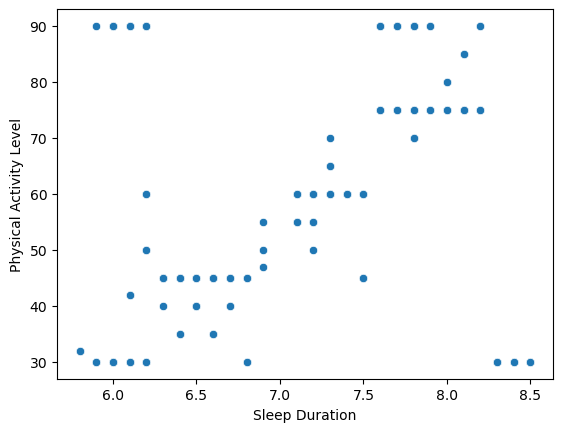

In [7]:
#Visualising the data

sns.scatterplot(data= sleep_df, x='Sleep Duration', y = 'Physical Activity Level')

In [8]:
#Checking a correlation matrix
numeric_df = sleep_df.select_dtypes(include='number')
Corr_mat = numeric_df.corr()
Corr_mat

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Person ID,1.000000,0.990516,0.296305,0.431612,0.149882,-0.394287,-0.225467,0.043844
Age,0.990516,1.000000,0.344709,0.473734,0.178993,-0.422344,-0.225606,0.057973
Sleep Duration,0.296305,0.344709,1.000000,0.883213,0.212360,-0.811023,-0.516455,-0.039533
Quality of Sleep,0.431612,0.473734,0.883213,1.000000,0.192896,-0.898752,-0.659865,0.016791
Physical Activity Level,0.149882,0.178993,0.212360,0.192896,1.000000,-0.034134,0.136971,0.772723
Stress Level,-0.394287,-0.422344,-0.811023,-0.898752,-0.034134,1.000000,0.670026,0.186829
Heart Rate,-0.225467,-0.225606,-0.516455,-0.659865,0.136971,0.670026,1.000000,-0.030309
Daily Steps,0.043844,0.057973,-0.039533,0.016791,0.772723,0.186829,-0.030309,1.000000


<Axes: >

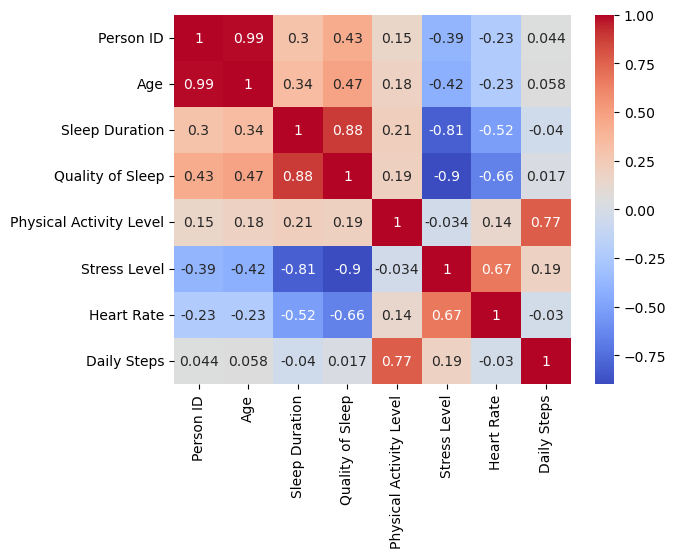

In [9]:
#Making a heatmap of the correlation matrix
sns.heatmap(Corr_mat, annot=True, cmap='coolwarm')


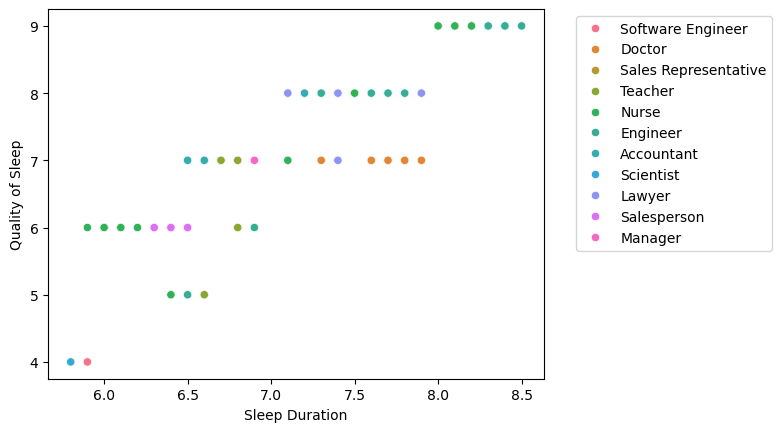

In [10]:
#Visualising if the sleep duration vs quality of sleep varies by occupation
sns.scatterplot(data = sleep_df, x = 'Sleep Duration', y= 'Quality of Sleep', hue = 'Occupation')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

<Axes: xlabel='Sleep Duration', ylabel='Stress Level'>

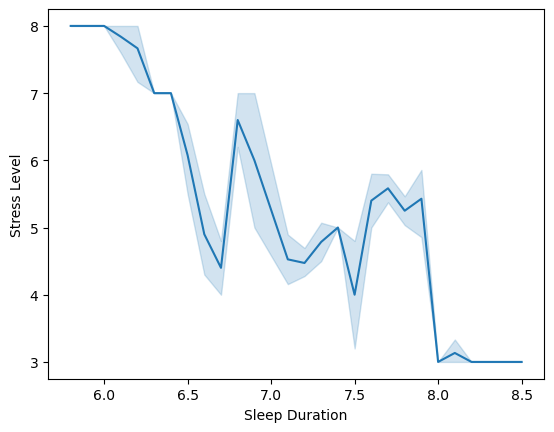

In [11]:
#Checking if productivity is linked to sleep
#We will check the relation between sleep duration and stress since they have a big negative co-relation

sns.lineplot(data = sleep_df, x= 'Sleep Duration', y= 'Stress Level')


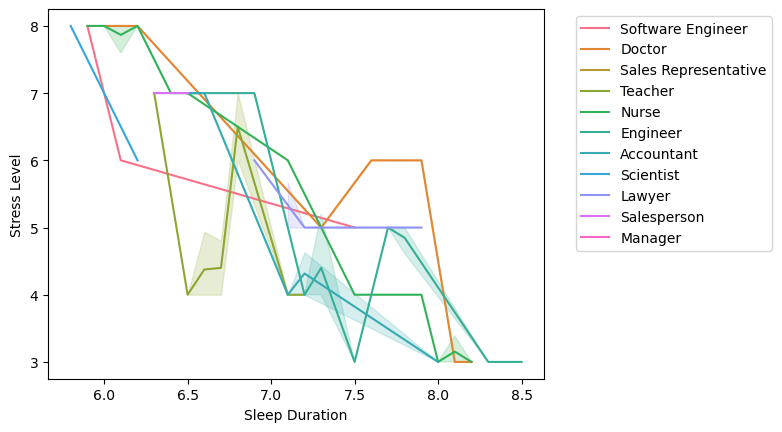

In [12]:
#Checking if this varies for each occupation
sns.lineplot(data = sleep_df, x= 'Sleep Duration', y= 'Stress Level', hue = "Occupation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Keeps the legend from blocking the graph



## Predicting the stress level with the help of linear regression


In [13]:
#Importing the library for statistical analysis

from sklearn.model_selection import train_test_split


In [14]:
#Splitting the data for training and testing

X = sleep_df[["Sleep Duration"]]
y = sleep_df["Stress Level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2)



In [15]:
print(X_train.shape)
print(X_test.shape)

(299, 1)
(75, 1)


In [16]:
#Importing linear regression from sklearn
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [17]:
#Fitting our data to the linear regression model (Training our model)
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
#Importing mean squared error to calculate error and for using the model to guess the stress levels for the test sleep

from sklearn.metrics import mean_squared_error

#Using the model to guess the stress levels for the test data

y_pred = model.predict(X_test)

#Calculating the MSE to validate the error rate of the model
mse_model = mean_squared_error(y_test, y_pred)

print(f"The mean squared error of our model is {mse_model}")

The mean squared error of our model is 1.035058462372206


In [19]:
#Checking the model coefficient (m) and the intercept (c). (y= mx + c)

print(f"For every hour of sleep, stress changes by: {model.coef_[0]:.2f}")
print(f"The 'Baseline' stress (at 0 hrs sleep) is: {model.intercept_:.2f}")

For every hour of sleep, stress changes by: -1.80
The 'Baseline' stress (at 0 hrs sleep) is: 18.21


In [ ]:
#Predicting stress for a specific amount of sleep
low_cust_sleep = [[5]]
high_cust_sleep = [[9]]

predicted_stress_5 = model.predict(low_cust_sleep)
predicted_stress_9 = model.predict(high_cust_sleep)

print(f"The predicted stress level for 5 hours of sleep is {predicted_stress_5[0]:.2f}")
print(f"The predicted stress level for 9 hours of sleep is {predicted_stress_9[0]:.2f}")

The predicted stress level for 5 hours of sleep is 9.23
The predicted stress level for 5 hours of sleep is 2.04


c:\Users\Admin\.conda\envs\code_study\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\.conda\envs\code_study\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


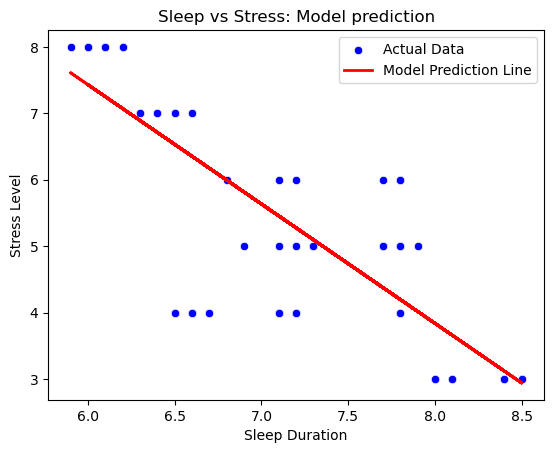

In [21]:
#Visualizing the model's prediction i.e. the Best fit line

#Plotting the actual data points from the test set
sns.scatterplot(x = X_test['Sleep Duration'], y = y_test, color= 'blue', label= 'Actual Data')

#Plotting the model's prediction line
plt.plot(X_test['Sleep Duration'], y_pred, color = "red", linewidth=2, label = "Model Prediction Line" )

plt.title('Sleep vs Stress: Model prediction')
plt.legend()


In [23]:
#Identifying the misses of the model

#Creating a Dataframe to compare results
results = pd.DataFrame({'Sleep_Duration': X_test['Sleep Duration'],
    'Actual_Stress': y_test,
    'Predicted_Stress': y_pred})

#Calculating the error (Residual)
results['Error'] = results['Actual_Stress'] - results['Predicted_Stress']

#Finding the ouliers
results['Abs_Error'] = results['Error'].abs()
outliers = results.sort_values(by = 'Abs_Error', ascending=False).head(5)

print(outliers)

     Sleep_Duration  Actual_Stress  Predicted_Stress     Error  Abs_Error
254             6.5              4          6.532247 -2.532247   2.532247
237             6.5              4          6.532247 -2.532247   2.532247
253             6.5              4          6.532247 -2.532247   2.532247
232             6.6              4          6.352645 -2.352645   2.352645
230             6.6              4          6.352645 -2.352645   2.352645
